## Instalar dependencias

In [ ]:
!pip install torch torchvision
!pip install pillow
!pip install numpy
!pip install matplotlib
!pip install scikit-image
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-njvdz91k
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-njvdz91k
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=01b58b2645e98ce3f0236f0ba22fe50a0a55c51e9e94640524b045e87c4223e4
  Stored in directory: /tmp/pip-ephem-wheel-cache-j59fzbr4/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


### Carga de Clip


In [ ]:
import clip
import torch
from PIL import Image

model, preprocess = clip.load("ViT-B/32")
device = "cuda" if torch.cuda.is_available() else "cpu"

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 116MiB/s]


In [ ]:
def clip_score(image_path, prompt):

  image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
  text = clip.tokenize([prompt]).to(device)

  with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

    similarity = torch.cosine_similarity(image_features, text_features).item()

  plt.imshow(Image.open(image_path))
  plt.axis("off")
  plt.title("Image")
  plt.show()

  return similarity

In [ ]:
prompt = "A cyberpunk city skyline at night"

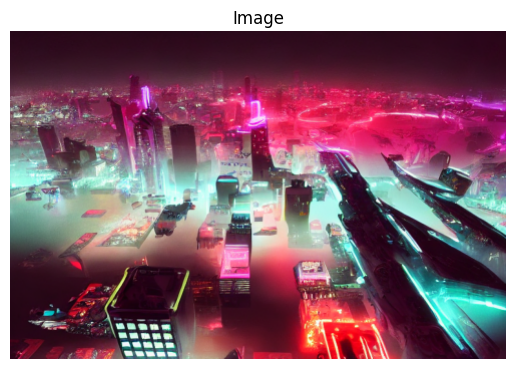

Clip score image 1: 0.29638671875


In [ ]:
clip_score_1 = clip_score("images/img1.png", prompt)

print("Clip score image 1:" ,clip_score_1)

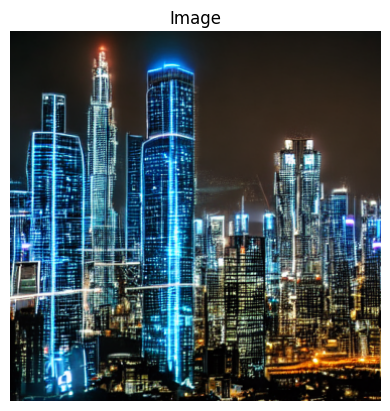

Clip score image 2: 0.315185546875


In [ ]:
clip_score_2 = clip_score("images/img2.png", prompt)

print("Clip score image 2:" ,clip_score_2)

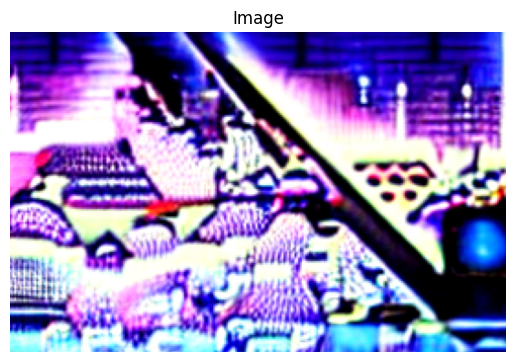

Clip score image 3: 0.249267578125


In [ ]:
clip_score_3 = clip_score("images/img3.png", prompt)

print("Clip score image 3:" ,clip_score_3)

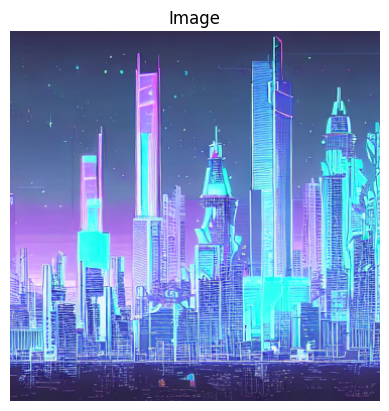

Clip score image 4: 0.32861328125


In [ ]:
clip_score_4 = clip_score("images/img4.png", prompt)

print("Clip score image 4:" ,clip_score_4)

### Comparar imagen derecha con izquierda

In [ ]:
import numpy as np
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

In [ ]:
def ssim_score(img_in):

  img = np.array(img_in)

  width = img.shape[1]

  #Se separan las imagenes en mitades
  left = img[:, :width//2]
  right = img[:, width//2:]

  min_width = min(left.shape[1], right.shape[1])

  left = left[:, :min_width]
  right = right[:, :min_width]

  #Regleja la imagen derecha
  right_flipped = np.fliplr(right)

  #Convierten a escala de grises
  left_gray = rgb2gray(left)
  right_gray = rgb2gray(right_flipped)

  score = ssim(
      left_gray,
      right_gray,
      data_range=1.0
  )

  #Visualizacion de las imagenes
  plt.figure(figsize=(12,4))

  plt.subplot(1,3,1)
  plt.imshow(left)
  plt.axis("off")
  plt.title("Izquierda")

  plt.subplot(1,3,2)
  plt.imshow(right)
  plt.axis("off")
  plt.title("Derecha")

  plt.subplot(1,3,3)
  plt.imshow(right_flipped)
  plt.axis("off")
  plt.title("Derecha reflejada")

  plt.show()

  return score

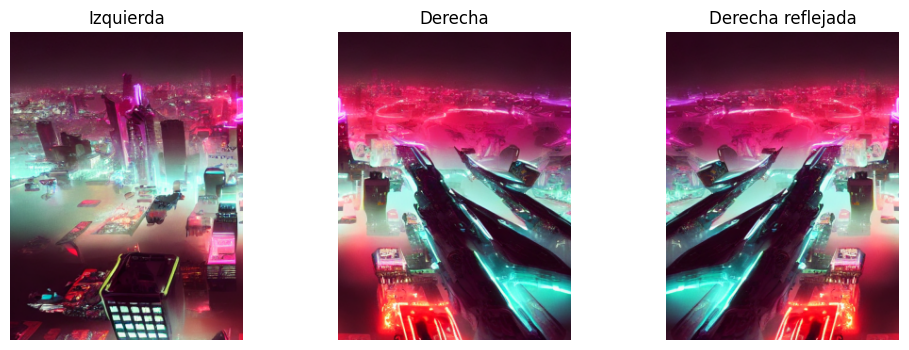

Score SSIM image 1: 0.26997011601809723


In [ ]:
img = Image.open("images/img1.png").convert("RGB")

score = ssim_score(img)
print("Score SSIM image 1:", score)

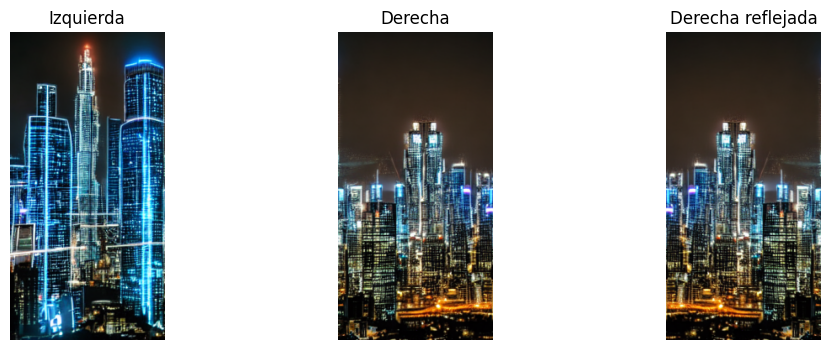

Score SSIM image 2: 0.17240199803217657


In [ ]:
img = Image.open("images/img2.png").convert("RGB")
score = ssim_score(img)
print("Score SSIM image 2:", score)

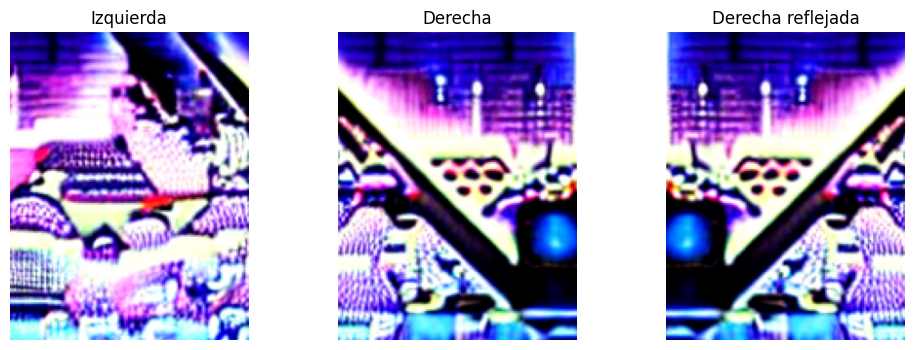

Score SSIM image 3: 0.06596182087194076


In [ ]:
img = Image.open("images/img3.png").convert("RGB")
score = ssim_score(img)
print("Score SSIM image 3:", score)

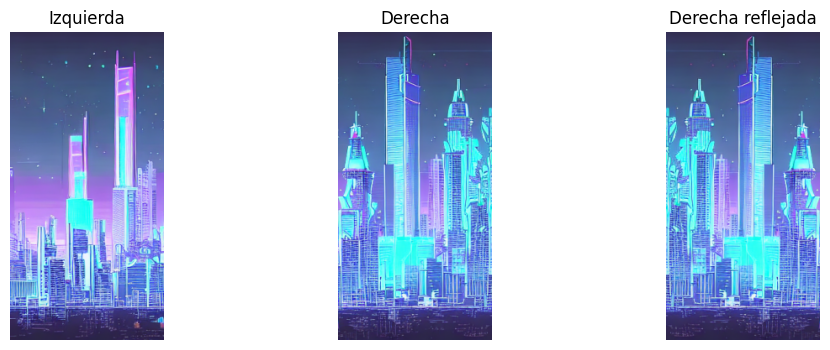

Score SSIM image 4: 0.2333763738837042


In [ ]:
img = Image.open("images/img4.png").convert("RGB")
score = ssim_score(img)
print("Score SSIM image 4:", score)